In [ ]:
## Q2. Unsupervised Learning

# 1. Data Preparation

# We scale all features before applying K-Means clustering.
# Scaling is essential because K-Means is distance-based, and features with larger values can dominate the clustering process.

In [6]:
!mamba install pandas
!mamba install scikit-learn

import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df = pd.read_csv("q2_customers.csv")

print(df.head())
print(df.info())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Scaled feature matrix shape:", X_scaled.shape)


mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.0829000000059605 seconds
All requested packages already installed.
mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.8805 seconds
All requested packages already installed.
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   nu

In [7]:
# 2. Elbow Method

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, threadpoolctl
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.3097000000178813 seconds
All requested packages already installed.


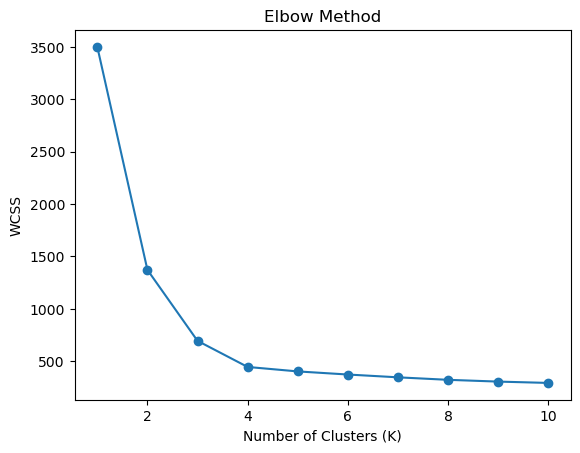

In [23]:
!mamba install threadpoolctl scikit-learn

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()


In [9]:
# The elbow point appears at K = 4
# This is where the reduction in WCSS slows down, indicating an optimal number of Clusters

In [10]:
# 3. K-Means Clustering

In [30]:
# Keep only the 6 intended features
features = ["age", "annual_spend", "visits_per_month",
            "basket_size", "days_since_last_visit",
            "num_categories_purchased"]

X_scaled = scaler.fit_transform(df[features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)
print("Cluster Centroids:\n", centroids)



Cluster Centroids:
          age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


In [13]:
# Cluster Interpretation

# - Cluster 0: High spenders with frequent visits
# - Cluster 1: Low spenders with infrequent visits
# - Cluster 2: Moderate customers
# - Cluster 3: High basket size but low frequency

# These clusters help businesses target different customer segments.

In [12]:
# 4 Dimensionality Reduction with PCA

In [31]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns,
    index=["PC1", "PC2"]
)
print("Feature Loadings:\n", loadings)


Explained Variance Ratio: [0.74353502 0.12525331]
Feature Loadings:
           age  annual_spend  visits_per_month  basket_size  \
PC1  0.406030      0.411626         -0.406048     0.398883   
PC2  0.041254     -0.103193         -0.080373    -0.203603   

     days_since_last_visit  num_categories_purchased   cluster  
PC1               0.365205                  0.405935  0.208716  
PC2              -0.278529                 -0.043264  0.927516  


In [17]:
# PC1 captures overall customer activity (spend + visits).
# PC2 captures recency and diversity of purchases.
# These components simplify high-dimensional data into interpretable axes.

In [20]:
# 5 Cluster Visualisation 

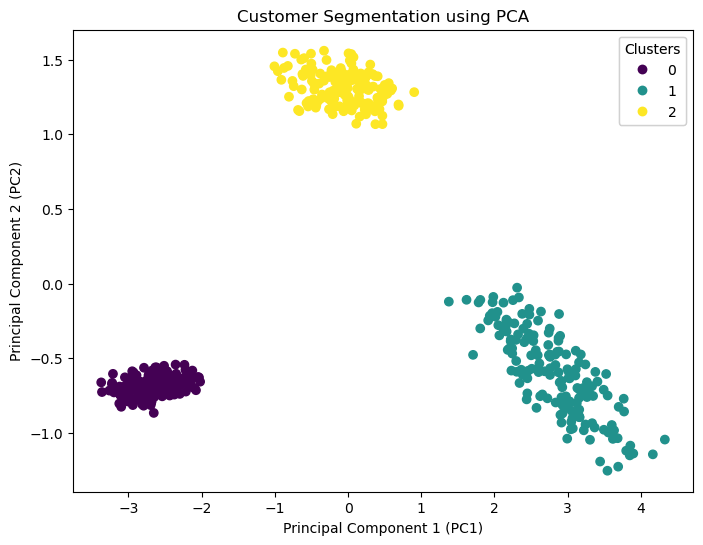

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot with clusters
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
)

# Title and labels
plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")

# Legend for cluster
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.show()

In [22]:
# The scatter plot visualizes customer segments in a reduced 2D space using PCA.
# Each color represents a different cluster, and clear separation between clusters
# indicates that K-Means has effectively grouped customers with similar behavior.
# Clusters that are well-separated suggest distinct customer segments, which can be targeted with different business strategies.
     